In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import os
import re
os.environ["PATH"] += os.pathsep + '/home/icb/mostafa.shahhosseini/miniconda3/envs/lupien/bin'
import pybedtools
import numpy as np
import pandas as pd
from tqdm import tqdm
import chromATAC as ca
# from chromATAC.integrated import IntData
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from concurrent.futures import ProcessPoolExecutor
# from chromATAC.al import mann_whitney_test, wilcoxon_test
from scipy.stats import ks_2samp
from scipy.stats import mannwhitneyu

import dash_bio

In [3]:
parent_dir = '/home/icb/mostafa.shahhosseini/data/lupien/'

In [4]:
os.chdir(parent_dir)

--------

In [5]:
grouping_tables = []
for f in os.listdir('./new-TCGA/groupings/'):
    if f.endswith('.csv'):
        with open(os.path.join('./new-TCGA/groupings/', f)) as t:
            d = pd.read_csv(t)
            grouping_tables += [d]

In [6]:
groups = pd.concat([i.iloc[:, 4:] for i in grouping_tables], axis=1)
groups = pd.concat([d.iloc[:, [2, 3]], groups], axis=1)

-----------

In [7]:
def pairwise_mannwhitneyu(df):
    results = []
    columns = df.columns
    for i in range(len(columns)):
        for j in range(len(columns)):
            col1 = columns[i]
            col2 = columns[j]
            if col1==col2:
                continue
            stat, p_value = mannwhitneyu(df[col1].astype(float), df[col2].astype(float))
            results.append((col1, col2, stat, p_value))
    results_df = pd.DataFrame(results, columns=['Column1', 'Column2', 'U-Statistic', 'P-Value'])
    return results_df

-----------

In [8]:
noclass = ["Simple_repeat","Satellite","rRNA","snRNA","srpRNA","scRNA","RNA","Low_complexity","Unknown","tRNA"]

_ = pd.read_csv('~/data/lupien/V2_files/repeat_cote_v1.csv')
te_meta = _.loc[:, ['repName', 'repClass', 'repFamily']]
te_meta = te_meta[te_meta['repClass'].map(lambda x: x not in noclass)]

te_meta['name'] = te_meta.apply(lambda row: f"{row['repClass']}_{row['repFamily']}_{row['repName']}", axis=1)
te_meta['name'] = te_meta['name'].apply(lambda x: x.replace('?', ''))

----

In [9]:
te_meta_ = te_meta.groupby('name').sample()

In [10]:
te_meta_['name'] = te_meta_['name'].apply(lambda x: x.replace('?', ''))

In [11]:
tes = os.listdir('./tes-TfIDF/')

In [12]:
ct=['ACC', 'BLCA', 'BRCA', 'CESC', 'CHOL', 'COAD', 'ESCA', 'GBM', 'HNSC',
       'KIRC', 'KIRP', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'MESO', 'PCPG', 'PRAD',
       'SKCM', 'STAD', 'TGCT', 'THCA', 'UCEC']

-----------

In [13]:
pvals = pd.read_csv('./TE_TCGA_groups6.tsv', sep='\t', index_col=0)

In [25]:
pvals['group'] = np.argmin(pvals, axis=1)

In [30]:
te_meta

,repName,repClass,repFamily,name
789830,Alu,SINE,Alu,SINE_Alu_Alu
789831,Alu,SINE,Alu,SINE_Alu_Alu
789832,Alu,SINE,Alu,SINE_Alu_Alu
789833,Alu,SINE,Alu,SINE_Alu_Alu
789834,Alu,SINE,Alu,SINE_Alu_Alu
...,...,...,...,...
5681410,hAT-N1_Mam,DNA,hAT-Tip100?,DNA_hAT-Tip100_hAT-N1_Mam
5681411,hAT-N1_Mam,DNA,hAT-Tip100?,DNA_hAT-Tip100_hAT-N1_Mam
5681412,hAT-N1a_Mam,DNA,hAT-Tip100,DNA_hAT-Tip100_hAT-N1a_Mam
5681413,hAT-N1a_Mam,DNA,hAT-Tip100,DNA_hAT-Tip100_hAT-N1a_Mam


In [36]:
pvals['repClass'] = pvals.index.map(lambda x: split_string(x)[0])

In [37]:
pvals['repFamily'] = pvals.index.map(lambda x: split_string(x)[1])

In [38]:
pvals['repName'] = pvals.index.map(lambda x: split_string(x)[-1])

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_bar(df, group_col, class_col, cmap='plasma'):
    # Calculate counts of each class within each group
    counts = df.groupby([group_col, class_col]).size().unstack().fillna(0)

    # Convert counts to percentages
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    percentages.plot(kind='bar', stacked=True, ax=ax, colormap=cmap)

    ax.set_ylabel('Percentage')
    ax.set_xlabel('Group')
    # ax.set_title(f'Stacked Bar Plot of {class_col} by {group_col}')
    
    # Adding the legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, title=class_col, bbox_to_anchor=(1.05, 1), loc='upper left', ncol=3)

    plt.tight_layout()
    return fig


In [106]:
pvals.to_csv('/home/icb/mostafa.shahhosseini/data/lupien/results/figure3/gp_te_pvals.csv')

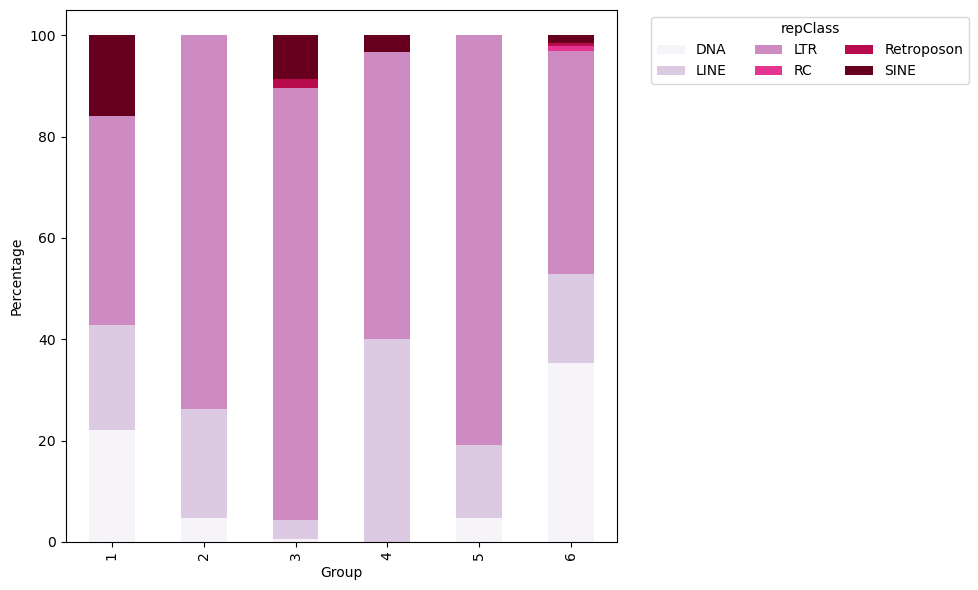

In [103]:
clsGp = plot_stacked_bar(pvals, 'group', 'repClass', cmap='PuRd')

In [104]:
clsGp.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSrpClass.png', bbox_inches='tight')
clsGp.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSrpClass.svg', bbox_inches='tight')

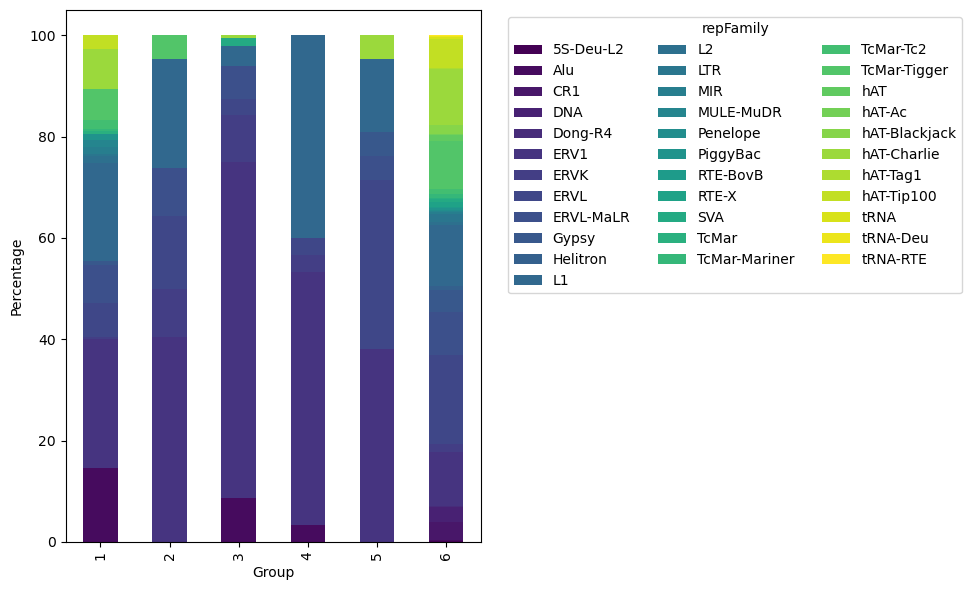

In [101]:
fml_gp = plot_stacked_bar(pvals, 'group', 'repFamily', cmap='viridis')

In [102]:
fml_gp.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSrpFamily.png', bbox_inches='tight')
fml_gp.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSrpFamily.svg', bbox_inches='tight')

In [94]:
ct = ct.rename({'Group':'Cancertype'}, axis=1)

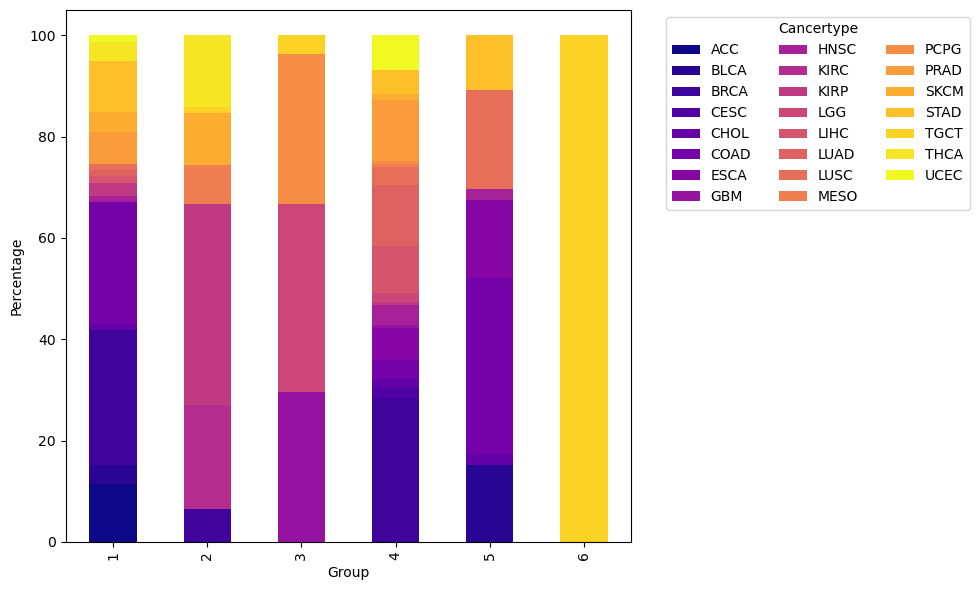

In [96]:
ct_fig = plot_stacked_bar(ct, 'groups6', 'Cancertype')

In [100]:
ct_fig.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSct.png', bbox_inches='tight')
ct_fig.savefig('/home/icb/mostafa.shahhosseini/data/lupien/figures/fig1/fig3-gpVSct.svg', bbox_inches='tight')

In [87]:
ct = pd.read_csv('/home/icb/mostafa.shahhosseini/data/lupien/new-TCGA/groupings/Grouping.tcga.2-6.csv')

In [88]:
ct

,Unnamed: 0,Row.names,SampleName,Group,groups2,groups3,groups4,groups5,groups6
0,1,0020e896-eb44-4d34-b3fc-bf55df812733,0020e896-eb44-4d34-b3fc-bf55df812733,SKCM,1,1,1,1,1
1,2,00919664-1563-46f2-a9de-290ba63f8ca0,00919664-1563-46f2-a9de-290ba63f8ca0,BRCA,1,1,1,1,1
2,3,00a595c5-0565-4289-878a-80ff4ba89d97,00a595c5-0565-4289-878a-80ff4ba89d97,BRCA,2,2,2,2,2
3,4,017ee2ce-79cb-475f-a497-46a8c57b8dd4,017ee2ce-79cb-475f-a497-46a8c57b8dd4,KIRP,1,1,1,1,1
4,5,01a439d2-f4ba-4c1f-9a13-4d8872058b08,01a439d2-f4ba-4c1f-9a13-4d8872058b08,PCPG,2,2,2,2,3
...,...,...,...,...,...,...,...,...,...
405,406,feccc9ed-3000-4549-be59-9604929f5b23,feccc9ed-3000-4549-be59-9604929f5b23,COAD,1,1,1,1,1
406,407,ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,COAD,2,3,3,4,5
407,408,ff883a34-10d4-4320-b37c-16fcdd637dbc,ff883a34-10d4-4320-b37c-16fcdd637dbc,THCA,2,2,2,2,2
408,409,ff9cbc57-60f4-45c7-82f6-7670199ba28c,ff9cbc57-60f4-45c7-82f6-7670199ba28c,BRCA,2,2,2,2,2


In [28]:
# Function to split the string into original parts
def split_string(s):
    # Find the positions of the first two underscores
    matches = [m.start() for m in re.finditer('_', s)]
    if len(matches) < 2:
        return None  # Not enough underscores to split into 3 parts
    
    # Split the string based on the positions of the first two underscores
    part1 = s[:matches[0]]
    part2 = s[matches[0] + 1:matches[1]]
    part3 = s[matches[1] + 1:]
    
    return part1, part2, part3

In [15]:
def read_and_check(N, pval=0.0001):
    pvals = pd.read_csv(f'./TE_TCGA_groups{N}.tsv', sep='\t', index_col=0)
    pvals = pvals.set_index('TE')
    pvals = pvals.merge(te_meta_.set_index('name'), left_index=True, right_on='name')
    pvals['p-check'] = pvals.apply(lambda x: sum([x[f'{i}']<pval for i in range(1, N+1)]), axis=1)
    return pvals['p-check'].value_counts()

In [16]:
def pval_check(pval=0.05):
    # Initialize an empty DataFrame to store results
    results = pd.DataFrame()
    # Run your checks for each N and store the results
    for i in range(2, 23):
        counts = read_and_check(i, pval)
        results = pd.concat([results, counts.rename(i)], axis=1)
    # Fill NaN values with 0
    results = results.fillna(0)
    results = results.div(results.sum()) * 100  # Converts counts to percentages
    # Plot the results as a stacked bar chart
    fig, ax=plt.subplots(1, 1, figsize=(12, 8))
    ax = results.T.plot(kind='bar', stacked=True, figsize=(10, 6), alpha=0.75, legend=False, ax=ax)
    plt.title(f'Pvalue-check for pvalue={pval} across different groupings')
    plt.xlabel('N value')
    plt.ylabel('Counts')
    
    # Adding a line connecting the '0' sections
    zero_counts = results.loc[0]  # Assuming 0 is the label for the sections with p-check count of 0
    plt.plot(zero_counts.index - 2, zero_counts.values, 'ko-', linewidth=2, markersize=5, label='Line connecting 0 counts')
    return fig

-------

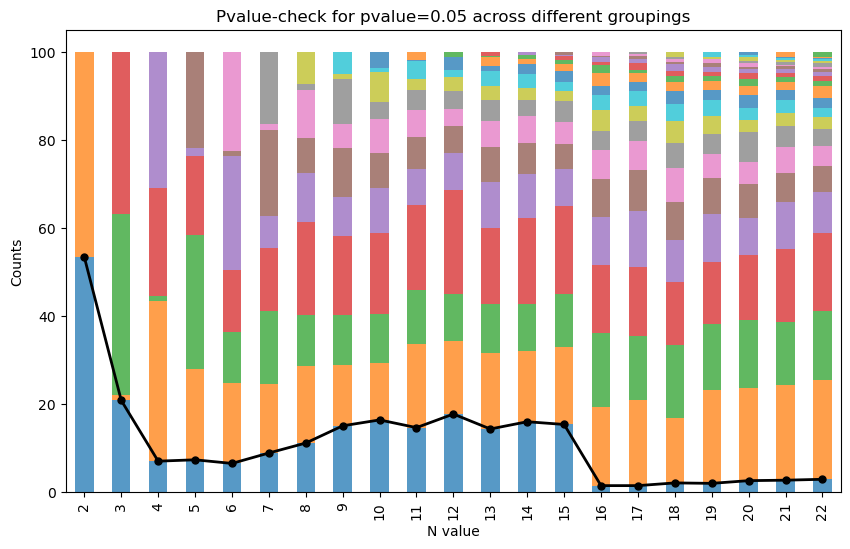

In [18]:
p=.05
f = pval_check(p)
f.savefig(f"./figures/p{str(p).replace('.', '0')}.png", bbox_inches='tight')

In [19]:
pvals = pd.read_csv('./TE_TCGA_groups6.tsv', sep='\t', index_col=0).dropna(axis=1).set_index('TE')

In [20]:
pvals

,1,2,3,4,5,6
TE,,,,,,
LTR_ERV1_LTR1E,1.143983e-01,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02
LTR_ERVL_LTR33A_,8.896955e-03,0.192266,1.911098e-03,0.008898,0.193388,1.304352e-05
DNA_DNA_UCON74,1.874117e-02,0.403834,3.859263e-01,0.102084,0.422843,9.897832e-05
SINE_Alu_AluYb9,2.695264e-02,0.253348,1.918829e-01,0.042431,0.281182,2.311104e-01
DNA_TcMar-Tigger_Tigger4b,1.019239e-26,0.050665,2.087064e-01,0.000117,0.214945,1.975825e-24
...,...,...,...,...,...,...
SINE_Alu_AluYc3,6.055635e-04,0.036418,6.412766e-06,0.025809,0.061303,6.053158e-04
DNA_hAT-Tip100_MER91B,1.970427e-05,0.053469,5.255672e-04,0.030600,0.082746,3.659417e-10
LTR_ERV1_LTR26B,3.183538e-01,0.397744,1.896251e-01,0.148185,0.373492,1.896322e-01


In [189]:
pvals['group'] = pvals.idxmin(axis=1)

<Axes: ylabel='count'>

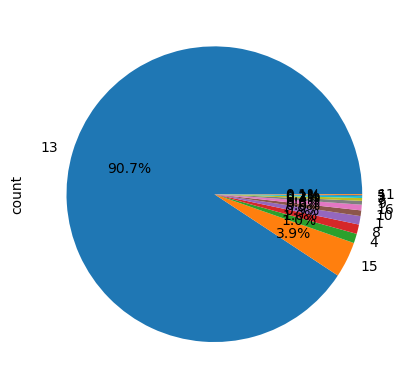

In [190]:
pvals['group'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [191]:
pvals['repClass'] = pvals.index.map(lambda x: x.split('_', 2)[0])

In [192]:
pvals['repFamily'] = pvals.index.map(lambda x: x.split('_', 2)[1])

In [193]:
pvals['repName'] = pvals.index.map(lambda x: x.split('_', 2)[2])

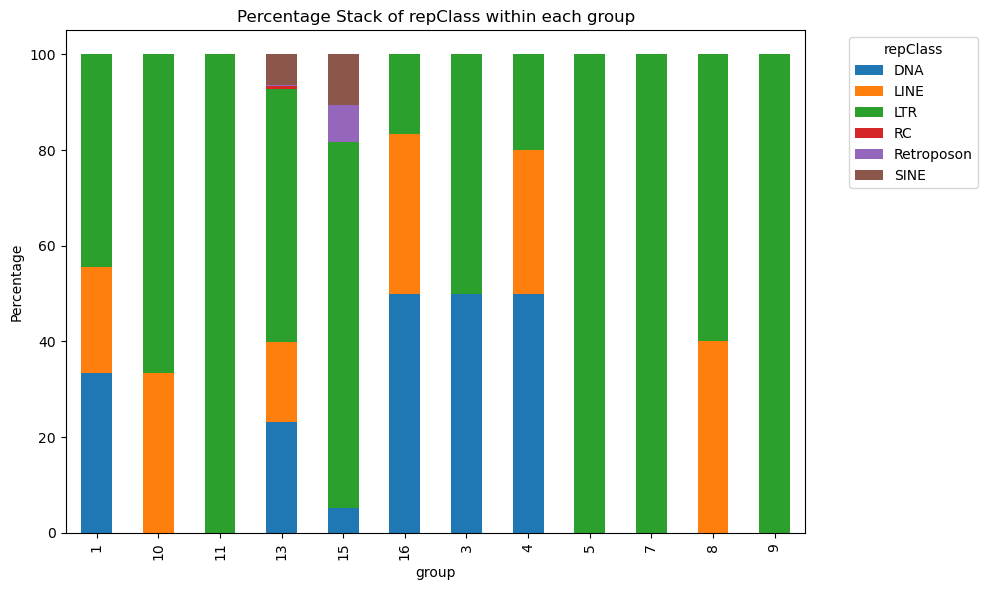

In [194]:
plot_stacked_percentage(pvals, 'group', 'repClass')

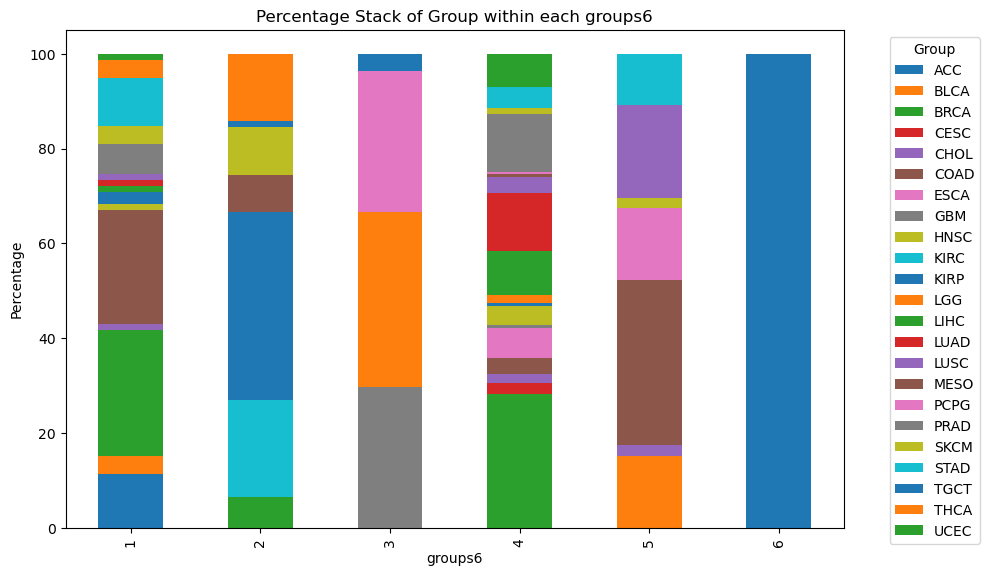

In [202]:
plot_stacked_percentage(groups, 'groups6', 'Group')

In [196]:
pvals['group'].value_counts()

group
13    881
15     38
4      10
8      10
1       9
10      6
16      6
9       4
7       3
3       2
5       1
11      1
Name: count, dtype: int64

In [186]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_stacked_percentage(df, x_cat, y_cat):
    """
    Plots a stacked bar chart with the percentage contribution of y_cat within each x_cat category.

    Parameters:
    df (pandas.DataFrame): Dataframe containing the data.
    x_cat (str): Column name for the x-axis category.
    y_cat (str): Column name for the category to be stacked.
    """
    # Creating a crosstab with normalization over the index (x-axis)
    crosstab = pd.crosstab(df[x_cat], df[y_cat], normalize='index') * 100

    # Plotting the stacked bar plot
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
    
    # Adding a legend and labels
    plt.legend(title=y_cat, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(x_cat)
    plt.ylabel('Percentage')
    plt.title(f'Percentage Stack of {y_cat} within each {x_cat}')
    
    # Show percentages on the bars
    for n, x in enumerate([rect.get_x() + rect.get_width()/2. for rect in ax.patches]):
        for rect, label in zip(ax.patches[n::len(crosstab.columns)], crosstab.iloc[:, n % len(crosstab.columns)]):
            height = rect.get_height()
            # ax.text(x, rect.get_y() + height / 2, f'{label:.1f}%', ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

# Example usage
# Assuming you have a DataFrame `df` loaded with appropriate categorical columns 'group', 'repClass', etc.
# plot_stacked_percentage(df, 'group', 'repClass')


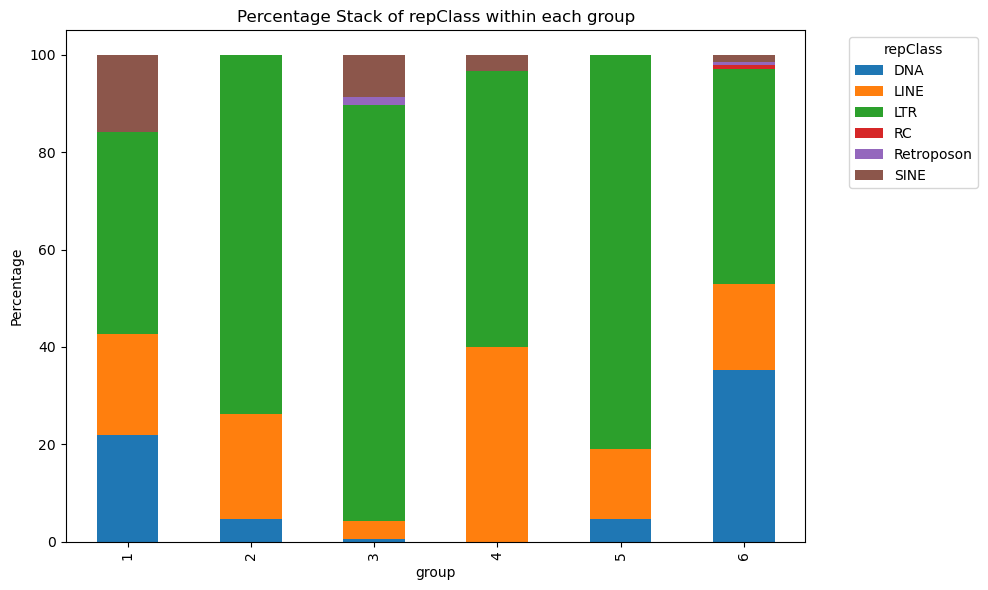

In [187]:
plot_stacked_percentage(pvals, 'group', 'repClass')

In [179]:
dfs['1']['repClass'].value_counts()

repClass
LTR     94
DNA     50
LINE    47
SINE    36
Name: count, dtype: int64

In [127]:
pvals

,1,2,3,4,5,6,group,repName,repClass,repFamily,name
683,0.114398,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02,4,LTR1E,LTR,ERV1,LTR_ERV1_LTR1E
68338,0.114398,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02,4,LTR1E,LTR,ERV1,LTR_ERV1_LTR1E
68339,0.114398,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02,4,LTR1E,LTR,ERV1,LTR_ERV1_LTR1E
71229,0.114398,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02,4,LTR1E,LTR,ERV1,LTR_ERV1_LTR1E
71231,0.114398,0.091085,4.939749e-02,0.048529,0.139872,5.922624e-02,4,LTR1E,LTR,ERV1,LTR_ERV1_LTR1E
...,...,...,...,...,...,...,...,...,...,...,...
5680231,0.000015,0.044533,7.561783e-07,0.000187,0.044361,1.401157e-18,6,MER68,LTR,ERVL,LTR_ERVL_MER68
5680647,0.000015,0.044533,7.561783e-07,0.000187,0.044361,1.401157e-18,6,MER68,LTR,ERVL,LTR_ERVL_MER68
5681183,0.000015,0.044533,7.561783e-07,0.000187,0.044361,1.401157e-18,6,MER68,LTR,ERVL,LTR_ERVL_MER68
5681205,0.000015,0.044533,7.561783e-07,0.000187,0.044361,1.401157e-18,6,MER68,LTR,ERVL,LTR_ERVL_MER68


In [126]:
dfs['1']

,1,2,3,4,5,6,group,repName,repClass,repFamily,name
91035,2.695264e-02,2.533481e-01,1.918829e-01,4.243061e-02,2.811815e-01,2.311104e-01,1,AluYb9,SINE,Alu,SINE_Alu_AluYb9
99266,2.695264e-02,2.533481e-01,1.918829e-01,4.243061e-02,2.811815e-01,2.311104e-01,1,AluYb9,SINE,Alu,SINE_Alu_AluYb9
124953,2.695264e-02,2.533481e-01,1.918829e-01,4.243061e-02,2.811815e-01,2.311104e-01,1,AluYb9,SINE,Alu,SINE_Alu_AluYb9
157701,2.695264e-02,2.533481e-01,1.918829e-01,4.243061e-02,2.811815e-01,2.311104e-01,1,AluYb9,SINE,Alu,SINE_Alu_AluYb9
161799,2.695264e-02,2.533481e-01,1.918829e-01,4.243061e-02,2.811815e-01,2.311104e-01,1,AluYb9,SINE,Alu,SINE_Alu_AluYb9
...,...,...,...,...,...,...,...,...,...,...,...
5681031,9.747272e-45,1.842732e-13,1.721092e-18,2.748715e-16,1.845463e-13,6.267787e-40,1,L1ME2,LINE,L1,LINE_L1_L1ME2
5681036,9.747272e-45,1.842732e-13,1.721092e-18,2.748715e-16,1.845463e-13,6.267787e-40,1,L1ME2,LINE,L1,LINE_L1_L1ME2
5681037,9.747272e-45,1.842732e-13,1.721092e-18,2.748715e-16,1.845463e-13,6.267787e-40,1,L1ME2,LINE,L1,LINE_L1_L1ME2
5681058,9.747272e-45,1.842732e-13,1.721092e-18,2.748715e-16,1.845463e-13,6.267787e-40,1,L1ME2,LINE,L1,LINE_L1_L1ME2


In [124]:
dfs.keys()

dict_keys(['1', '2', '3', '4', '5', '6'])

In [121]:
pvals.groupby('group').count()

,1,2,3,4,5,6,repName,repClass,repFamily,name
group,,,,,,,,,,
1,3045763,3045763,3045763,3045763,3045763,3045763,3045763,3045763,3045763,3045763
2,86891,86891,86891,86891,86891,86891,86891,86891,86891,86891
3,149128,149128,149128,149128,149128,149128,149128,149128,149128,149128
4,16446,16446,16446,16446,16446,16446,16446,16446,16446,16446
5,42259,42259,42259,42259,42259,42259,42259,42259,42259,42259
6,1472208,1472208,1472208,1472208,1472208,1472208,1472208,1472208,1472208,1472208


In [16]:
def plot_groupped_pvalues(pvals, group='repClass', figsizes=[(10, 10), (15, 20)]):
    pvals = pvals.set_index('TE')
    pvals = pvals.merge(te_meta_.set_index('name'), left_index=True, right_on='name')
    rfcls = {n:df for n, df in pvals.groupby('repClass')}
    clss=pvals['repClass'].unique()    
    fig1 = plt.figure(figsize=figsizes[0])
    plt.title('specificity of accessibility of elements \n from different TE subfamilies over different groups', fontsize=10)
    sns.boxplot(pvals, fliersize=.3)
    sns.stripplot(pvals, size=3, alpha=0.4, color='tan')
    plt.axhline(y=0.05, linestyle='--', color='gold')
    plt.xticks(fontsize=8, rotation=90)
    plt.ylabel('Pvalue')
    plt.xlabel('groups')
    fig2, axs = plt.subplots(3, 3, figsize=figsizes[1])
    plt.xticks(rotation=90, fontsize=8)
    for i, c in enumerate(clss):
        ax = axs.flatten()[i]
        ax.set_title(f"specificity of accessibility of elements \n FROM {c.replace('?', '')} {group} \n from different TE subfamilies over different groups", fontsize=8)
        sns.boxplot(rfcls[c], fliersize=.3, ax=ax)
        sns.stripplot(rfcls[c], ax=ax, color='tan', size=4, alpha=.4)
        ax.set_ylabel('Pvalue')
        ax.set_xlabel('groups')
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=7, rotation=90)  # Adjust fontsize as needed
        ax.axhline(y=0.05,  linestyle='--', color='gold')
    return fig1, fig2

In [27]:
pvals['TE'] = pvals.index.map(lambda x: x.split('|')[0])

In [29]:
pvals = pvals.set_index('TE')
pvals = pvals.merge(te_meta_.set_index('name'), left_index=True, right_on='name')
rfcls = {n:df for n, df in pvals.groupby('repClass')}

In [31]:
groups

,SampleName,Group,groups2,groups3,groups4,groups5,groups6,groups7,groups8,groups9,...,groups17,groups18,groups19,groups20,groups21,groups22,groups23,groups24,groups25,groups26
0,0020e896-eb44-4d34-b3fc-bf55df812733,SKCM,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,00919664-1563-46f2-a9de-290ba63f8ca0,BRCA,1,1,1,1,1,1,2,2,...,2,2,2,2,2,2,2,2,2,2
2,00a595c5-0565-4289-878a-80ff4ba89d97,BRCA,2,2,2,2,2,2,3,3,...,3,3,3,3,3,3,3,3,3,3
3,017ee2ce-79cb-475f-a497-46a8c57b8dd4,KIRP,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
4,01a439d2-f4ba-4c1f-9a13-4d8872058b08,PCPG,2,2,2,2,3,3,4,4,...,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,feccc9ed-3000-4549-be59-9604929f5b23,COAD,1,1,1,1,1,1,2,2,...,15,16,16,16,17,17,18,18,19,19
406,ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,COAD,2,3,3,4,5,6,7,8,...,12,12,12,12,13,13,13,13,14,14
407,ff883a34-10d4-4320-b37c-16fcdd637dbc,THCA,2,2,2,2,2,2,3,3,...,17,18,19,20,21,22,23,23,24,24
408,ff9cbc57-60f4-45c7-82f6-7670199ba28c,BRCA,2,2,2,2,2,2,3,3,...,3,3,3,3,3,3,3,3,3,3


In [30]:
pvals

,0020e896-eb44-4d34-b3fc-bf55df812733,00919664-1563-46f2-a9de-290ba63f8ca0,00a595c5-0565-4289-878a-80ff4ba89d97,017ee2ce-79cb-475f-a497-46a8c57b8dd4,01a439d2-f4ba-4c1f-9a13-4d8872058b08,02f56cb3-dc15-4dbd-a508-cbb14154e1bd,0338ad51-21c2-4607-a60e-099fbe0693ba,03c50711-9e22-4275-90aa-b6cd56584437,03d0944c-b853-4b09-bd82-5db368275033,03e41ffe-e1ac-4575-ace5-c376628c890e,...,fc3fe6ee-8cec-4e29-90c2-0ceebbf66adc,fc9a595e-2077-49d8-a8a5-f026f8a7345e,feccc9ed-3000-4549-be59-9604929f5b23,ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,ff883a34-10d4-4320-b37c-16fcdd637dbc,ff9cbc57-60f4-45c7-82f6-7670199ba28c,ffb8a92c-4f13-4b72-abee-d6f5c5d8f66f,repName,repClass,repFamily
name,,,,,,,,,,,,,,,,,,,,,
LTR_ERV1_LTR1E,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,LTR1E,LTR,ERV1
LTR_ERV1_LTR1E,0.0,0.003082,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,LTR1E,LTR,ERV1
LTR_ERV1_LTR1E,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,LTR1E,LTR,ERV1
LTR_ERV1_LTR1E,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.004688,0.0,0.0,0.0,0.0,LTR1E,LTR,ERV1
LTR_ERV1_LTR1E,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,LTR1E,LTR,ERV1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LTR_ERVL_MER68,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,MER68,LTR,ERVL
LTR_ERVL_MER68,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,MER68,LTR,ERVL
LTR_ERVL_MER68,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,MER68,LTR,ERVL


In [228]:
for group in ['Group']:
    pv = pd.read_csv(f'./TE_TCGA_{group}.tsv', sep='\t', index_col=0).dropna(axis=1)
    fig1, fig2 = plot_groupped_pvalues(pv)
    fig1.savefig(f'./pvals/TE_TCGA_overGroup:{group}_overAll.png', bbox_inches='tight')
    fig2.savefig(f'./pvals/TE_TCGA_overGroup:{group}_category.pdf', bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: './TE_TCGA_Group.tsv'

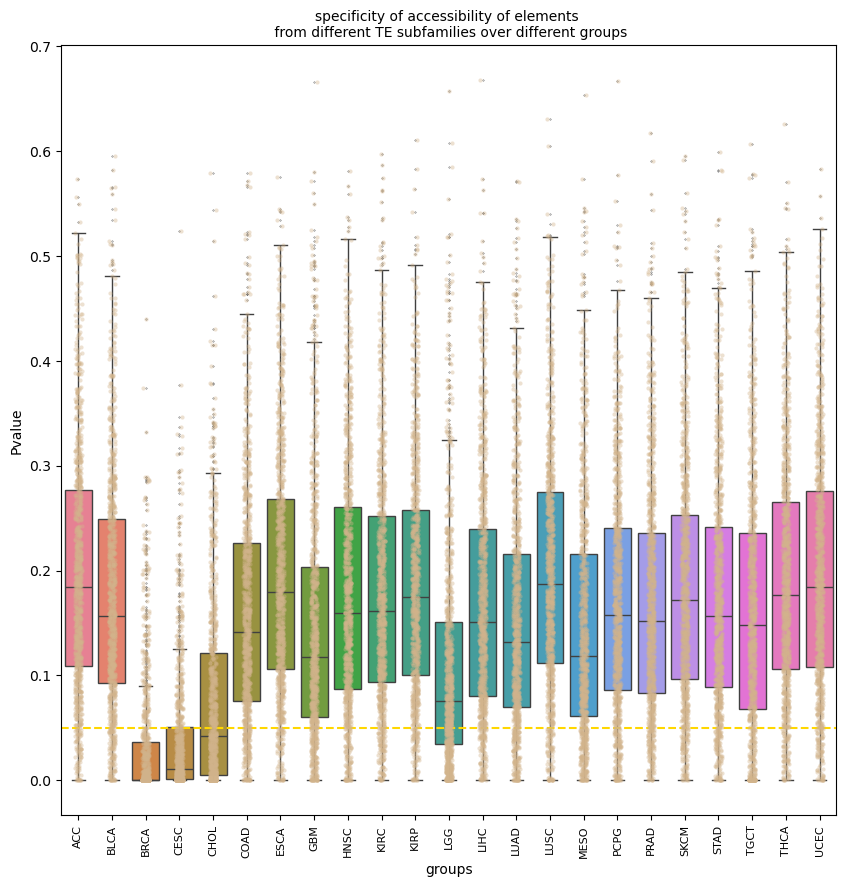

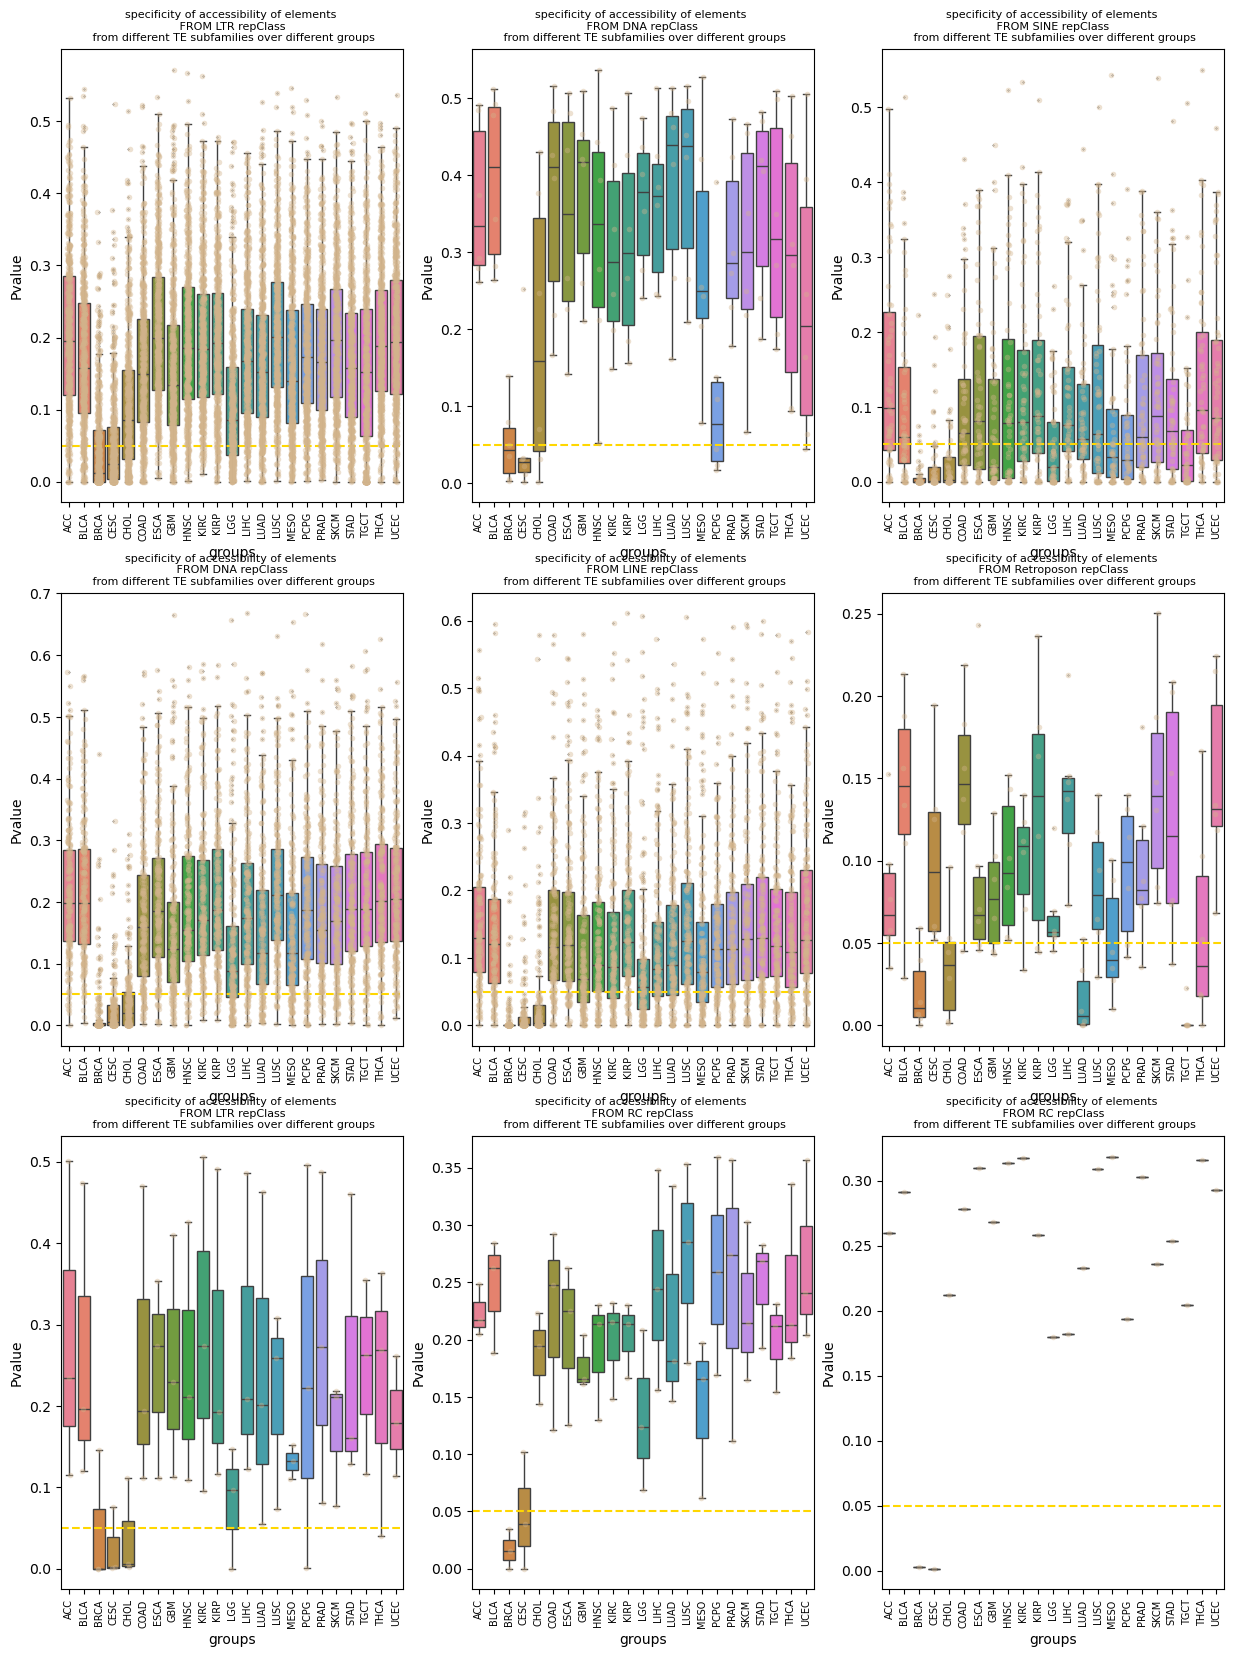

In [233]:
pv = pd.read_csv('./TE-TCGA_pvalues.tsv', sep='\t', index_col=0).dropna(axis=1)
fig1, fig2 = plot_groupped_pvalues(pv)
fig1.savefig(f'./pvals/TE_TCGA_overGroup:{group}_overAll.png', bbox_inches='tight')
fig2.savefig(f'./pvals/TE_TCGA_overGroup:{group}_category.pdf', bbox_inches='tight')

In [315]:
pv_dct ={i:pv[pv[i]<=0.05].sort_values(i) for i in pv.set_index('TE').columns}

In [319]:
pv_dct['ACC']

,ACC,BLCA,BRCA,CESC,CHOL,COAD,ESCA,GBM,HNSC,KIRC,...,LUSC,MESO,PCPG,PRAD,SKCM,STAD,TGCT,THCA,UCEC,TE
0,2.072489e-13,0.195517,3.193337e-02,2.182057e-02,8.137636e-02,0.207556,0.241738,0.236083,0.262529,0.138824,...,0.170102,0.245712,0.121659,0.239568,0.253135,0.183024,0.155516,0.200905,0.200778,LTR_ERV1_LTR61
0,3.026495e-13,0.233149,2.022543e-01,2.421931e-02,9.427398e-02,0.179397,0.165700,0.188309,0.185591,0.227642,...,0.159509,0.200076,0.221636,0.193948,0.254748,0.241936,0.256705,0.188385,0.170735,LTR_ERV1_LTR15
0,8.883171e-12,0.347627,4.113600e-02,3.847586e-05,1.021370e-01,0.193811,0.331571,0.070364,0.140855,0.342193,...,0.259915,0.272780,0.344602,0.333219,0.041555,0.216199,0.340901,0.287504,0.318574,DNA_PiggyBac_MER85
0,1.244075e-07,0.022556,1.535275e-01,7.502601e-02,1.749676e-01,0.271368,0.284434,0.100152,0.302134,0.172535,...,0.298662,0.304087,0.224228,0.071919,0.169411,0.251855,0.268863,0.036931,0.302891,LTR_ERVK_LTR5A
0,1.388312e-05,0.051560,1.627071e-02,2.522756e-03,4.888453e-03,0.127455,0.106751,0.144253,0.180465,0.173159,...,0.056255,0.070738,0.177998,0.159495,0.080137,0.115638,0.161099,0.158857,0.094345,LTR_ERV1_MER65A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,4.747625e-02,0.000259,7.988094e-304,1.198145e-17,1.198148e-17,0.043729,0.000020,0.000004,0.002222,0.002137,...,0.018727,0.001329,0.001332,0.000103,0.002071,0.018486,0.018486,0.006227,0.029432,SINE_Alu_AluSq2
0,4.760350e-02,0.035692,2.605910e-27,1.194548e-03,2.833320e-03,0.056431,0.058567,0.080206,0.023064,0.007040,...,0.057808,0.084676,0.053870,0.025078,0.040830,0.059566,0.046557,0.032972,0.050577,LINE_L1_L1PA5
0,4.802662e-02,0.049650,4.581828e-55,3.439418e-02,4.814673e-02,0.054261,0.004760,0.000203,0.049225,0.030406,...,0.031006,0.047920,0.011446,0.046514,0.030117,0.042868,0.040435,0.001299,0.050761,LTR_ERVL-MaLR_THE1B
0,4.816529e-02,0.042977,1.225934e-55,8.402641e-04,8.402641e-04,0.052844,0.105918,0.068889,0.052010,0.051932,...,0.030981,0.079485,0.112794,0.090498,0.086813,0.091931,0.028985,0.023303,0.093296,LINE_L1_L1ME3Cz


In [243]:
pv_dct['BRCA'].sort_values('')

,ACC,BLCA,BRCA,CESC,CHOL,COAD,ESCA,GBM,HNSC,KIRC,...,LUSC,MESO,PCPG,PRAD,SKCM,STAD,TGCT,THCA,UCEC,TE
0,0.233398,0.174188,3.538432e-02,1.163143e-01,5.918295e-02,0.170991,0.262124,0.136298,0.267358,0.201685,...,0.263716,0.075348,0.248814,0.212651,0.233487,0.170814,1.540962e-01,0.252611,0.242839,LTR_ERV1_LTR1E
0,0.174530,0.116622,2.024640e-10,1.139545e-04,1.499068e-02,0.163246,0.120488,0.087000,0.155816,0.183582,...,0.171375,0.084638,0.194311,0.099838,0.132548,0.183828,1.047871e-01,0.179042,0.084251,LTR_ERVL_LTR33A_
0,0.292993,0.342862,4.976541e-02,2.247243e-02,7.079895e-02,0.396695,0.226909,0.421154,0.394242,0.199183,...,0.424417,0.204611,0.391262,0.424435,0.219154,0.420216,3.500174e-01,0.451392,0.245479,DNA_DNA_UCON74
0,0.397388,0.378759,1.824000e-02,4.949420e-02,7.249446e-02,0.338233,0.346267,0.389523,0.365529,0.264085,...,0.358487,0.253239,0.325668,0.345456,0.289602,0.363336,2.700293e-01,0.396875,0.384452,SINE_Alu_AluYb9
0,0.159787,0.171828,6.587539e-14,9.784517e-07,7.671000e-04,0.148384,0.103044,0.103136,0.013184,0.158673,...,0.164038,0.019384,0.162841,0.177211,0.078141,0.170549,1.892671e-01,0.151220,0.183311,DNA_TcMar-Tigger_Tigger4b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.031336,0.045310,1.036200e-73,2.919056e-08,2.919056e-08,0.008764,0.031144,0.060117,0.004500,0.005635,...,0.053521,0.061739,0.057012,0.050516,0.079457,0.082688,3.214167e-02,0.040714,0.068675,LINE_L1_L1ME3G
0,0.089228,0.083538,8.826767e-70,3.932087e-04,3.932089e-04,0.072854,0.064620,0.034784,0.042316,0.002219,...,0.090979,0.045727,0.065904,0.089889,0.071515,0.069208,6.842827e-02,0.020033,0.047461,LINE_L1_L1ME2
0,0.202625,0.048535,6.711111e-03,9.445245e-02,9.727584e-02,0.131415,0.195763,0.067891,0.128462,0.209452,...,0.120140,0.111912,0.109374,0.135950,0.157755,0.113260,3.496559e-11,0.154642,0.154868,SINE_Alu_AluYc3
0,0.136278,0.083908,2.931328e-04,9.593498e-07,6.476818e-02,0.038682,0.217290,0.159951,0.135059,0.153799,...,0.256297,0.057716,0.258423,0.124512,0.257613,0.106074,2.427565e-01,0.201498,0.253236,DNA_hAT-Tip100_MER91B


In [245]:
groups['Group'].value_counts()

Group
BRCA    75
COAD    41
KIRP    34
PRAD    26
LUAD    22
STAD    21
ESCA    18
LIHC    17
KIRC    16
LUSC    16
THCA    14
LGG     13
SKCM    13
UCEC    13
BLCA    10
HNSC     9
ACC      9
TGCT     9
PCPG     9
GBM      9
MESO     7
CHOL     5
CESC     4
Name: count, dtype: int64

In [247]:
g = 'Group'

In [258]:
df = pd.read_csv('./TEs_TCGA.tsv', sep='\t')

In [214]:
dff = pd.read_csv('./TEs_TCGA_TfIDF.tsv', sep='\t', index_col=0)

In [215]:
dff = dff.T

In [217]:
dff = dff.merge(groups, right_index=True, left_index=True)

In [219]:
groups

,Group,groups2,groups3,groups4,groups5,groups6,groups7,groups8,groups9,groups10,...,groups17,groups18,groups19,groups20,groups21,groups22,groups23,groups24,groups25,groups26
SampleName,,,,,,,,,,,,,,,,,,,,,
0020e896-eb44-4d34-b3fc-bf55df812733,SKCM,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
00919664-1563-46f2-a9de-290ba63f8ca0,BRCA,1,1,1,1,1,1,2,2,2,...,2,2,2,2,2,2,2,2,2,2
00a595c5-0565-4289-878a-80ff4ba89d97,BRCA,2,2,2,2,2,2,3,3,3,...,3,3,3,3,3,3,3,3,3,3
017ee2ce-79cb-475f-a497-46a8c57b8dd4,KIRP,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
01a439d2-f4ba-4c1f-9a13-4d8872058b08,PCPG,2,2,2,2,3,3,4,4,4,...,4,4,4,4,4,4,4,4,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
feccc9ed-3000-4549-be59-9604929f5b23,COAD,1,1,1,1,1,1,2,2,2,...,15,16,16,16,17,17,18,18,19,19
ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,COAD,2,3,3,4,5,6,7,8,9,...,12,12,12,12,13,13,13,13,14,14
ff883a34-10d4-4320-b37c-16fcdd637dbc,THCA,2,2,2,2,2,2,3,3,3,...,17,18,19,20,21,22,23,23,24,24


In [223]:
dffv = dff.iloc[:, :-1]

In [221]:
labels = dff.iloc[:, -1]

In [ ]:
ddd = apply_pca(dffv, 2)

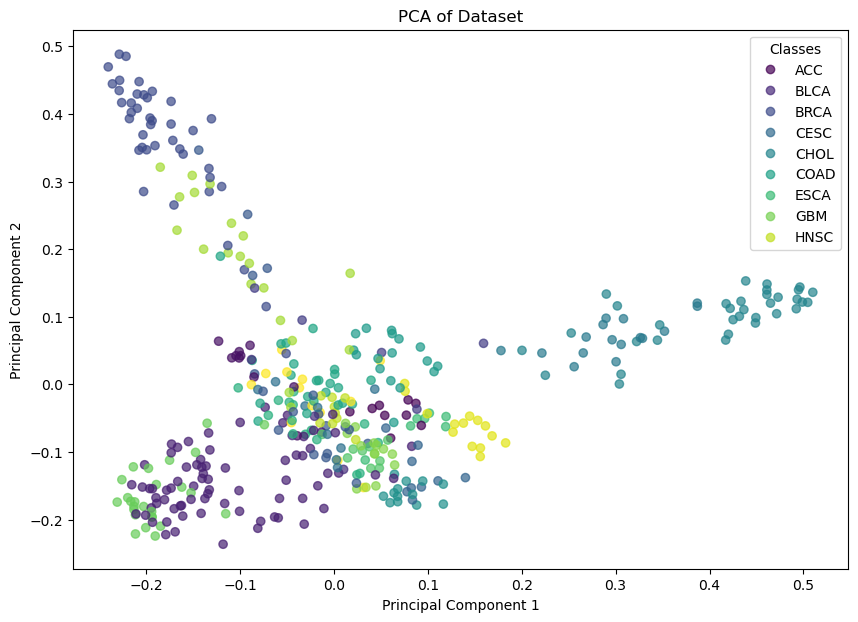

In [312]:
fig2 = plot_pca(dffv, labels)

In [263]:
df = df.set_index('Unnamed: 0').T

In [268]:
groups.loc[:, ['SampleName', 'Group']].set_index('SampleName')

,Group
SampleName,
0020e896-eb44-4d34-b3fc-bf55df812733,SKCM
00919664-1563-46f2-a9de-290ba63f8ca0,BRCA
00a595c5-0565-4289-878a-80ff4ba89d97,BRCA
017ee2ce-79cb-475f-a497-46a8c57b8dd4,KIRP
01a439d2-f4ba-4c1f-9a13-4d8872058b08,PCPG
...,...
feccc9ed-3000-4549-be59-9604929f5b23,COAD
ff4d2e83-f6aa-4e98-ae75-11a97a7d8253,COAD
ff883a34-10d4-4320-b37c-16fcdd637dbc,THCA


In [271]:
df = df.merge(groups.loc[:, ['SampleName', 'Group']], left_index=True, right_on='SampleName').set_index('SampleName')

In [275]:
dfv = df.drop(columns=['Group']).values

In [277]:
dfv = dfv.flatten()

In [278]:
pdfv = dfv[np.nonzero(dfv)]

In [285]:
pvls_m = df.groupby('Group').mean()

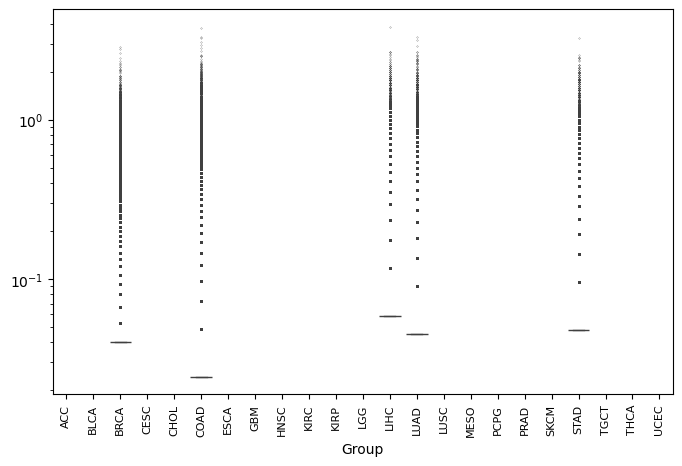

In [287]:
fig = plt.figure(figsize=(8, 5))
sns.boxplot(pvls_m.T, log_scale=True, fliersize=0.2)
plt.xticks(fontsize=8, rotation=90)
plt.show()
fig.savefig('pvls_m_raw.png')

In [211]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

def apply_pca(df: pd.DataFrame, n_components: int) -> pd.DataFrame:
    """
    Apply PCA to the input DataFrame and return the desired number of components for each sample.

    Parameters:
    df (pd.DataFrame): Input DataFrame with samples as rows and features as columns.
    n_components (int): Number of principal components to return.

    Returns:
    pd.DataFrame: DataFrame with the principal components for each sample.
    """
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(df)
    pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(n_components)])
    
    return pca_df

def plot_pca(df: pd.DataFrame, labels: pd.Series):
    """
    Perform PCA on the DataFrame, plot the first two principal components, and color based on the labels.

    Parameters:
    df (pd.DataFrame): Input DataFrame with samples as rows and features as columns.
    labels (pd.Series): Series with categorical labels for each sample.
    """
    # Apply PCA to get the first two components
    pca_df = apply_pca(df, 2)

    # Encode labels to integers for color mapping
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    label_names = label_encoder.classes_

    # Create a scatter plot
    fig = plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=encoded_labels, cmap='viridis', alpha=0.7)
    
    # Add title and labels
    plt.title('PCA of Dataset')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    
    # Create a legend
    handles, _ = scatter.legend_elements()
    legend_labels = [label_names[i] for i in range(len(label_names))]
    plt.legend(handles, legend_labels, title="Classes")
    
    # Show plot
    plt.show()
    return fig

def ploty_pca(pca_df: pd.DataFrame, labels: pd.Series, g):
    """
    Perform PCA on the DataFrame, plot the first two principal components, and color based on the labels.

    Parameters:
    df (pd.DataFrame): Input DataFrame with samples as rows and features as columns.
    labels (pd.Series): Series with categorical labels for each sample.
    """
    # Encode labels to integers for color mapping
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)
    label_names = label_encoder.classes_

    # Create a scatter plot
    fig = plt.figure(figsize=(10, 7))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=encoded_labels, cmap='viridis', alpha=0.7)
    
    # Add title and labels
    plt.title(g)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')

    # Create a legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(i)), 
                              markersize=10, label=label) for i, label in enumerate(label_names)]
    plt.legend(handles=legend_elements, title="Classes")
    
    # Show plot
    plt.show()
    return fig
# Example usage:
# df = pd.read_csv('your_data.csv')
# labels = pd.Series(['cat1', 'cat2', 'cat1', 'cat3', ...])  # Replace with your actual labels
# plot_pca(df, labels)


In [291]:
dfv = df.iloc[:, :-1]

In [293]:
labels = df.iloc[:, -1]

In [314]:
fig2.savefig('apca.png')

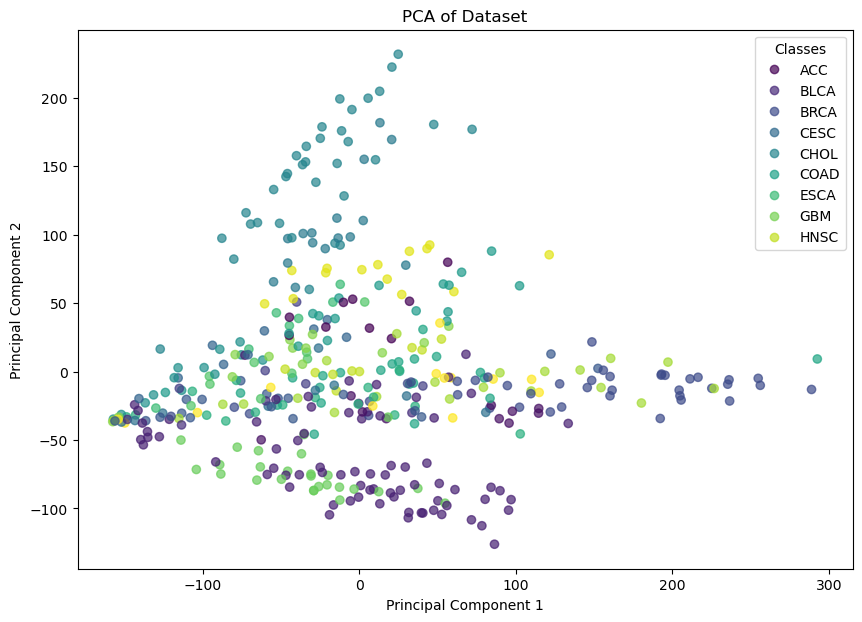

In [298]:
fig = plot_pca(dfv, labels)

In [281]:
gr = groups.set_index('SampleName').loc[:, ['Group']]

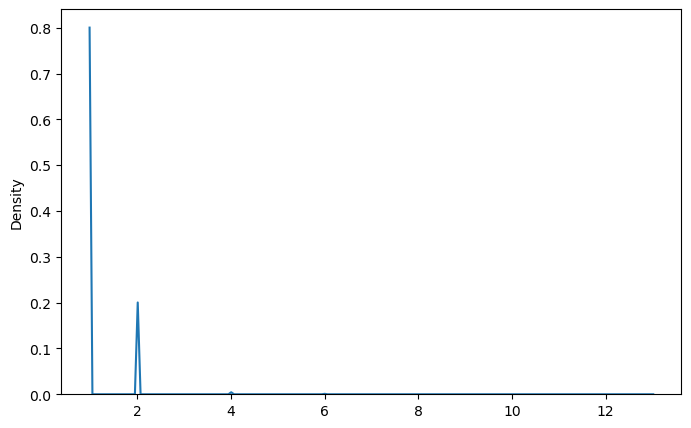

In [280]:
fig = plt.figure(figsize=(8, 5))
sns.kdeplot(pdfv)
plt.show()
fig.savefig('pdfv.png')

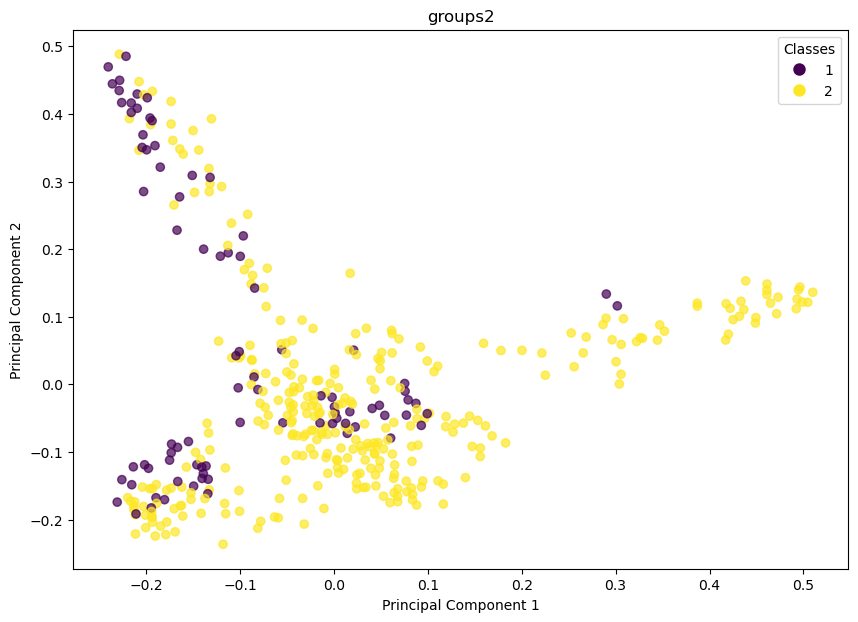

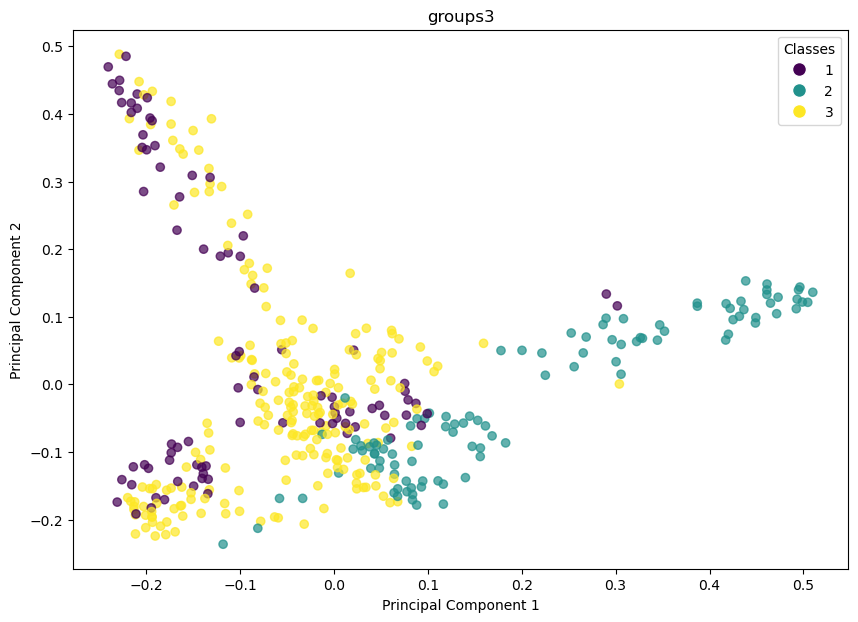

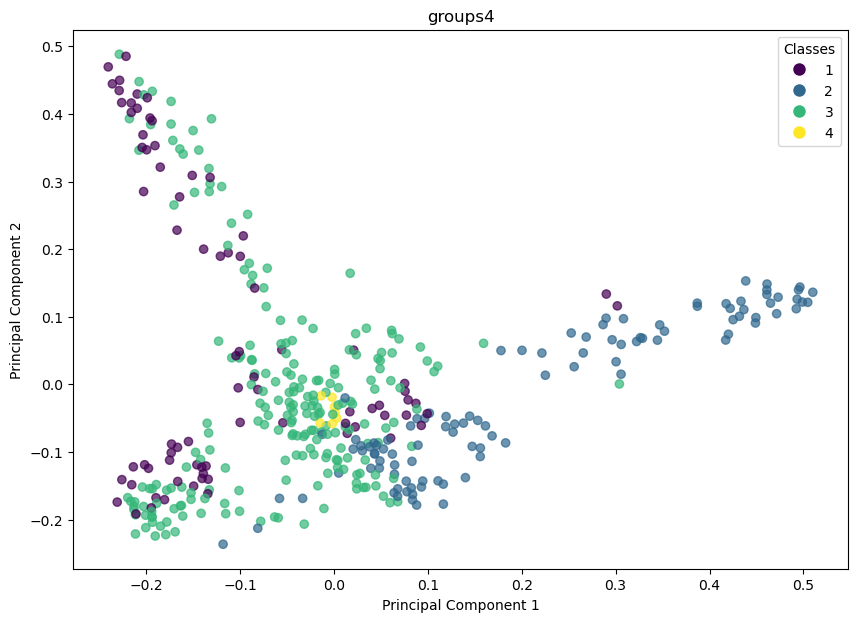

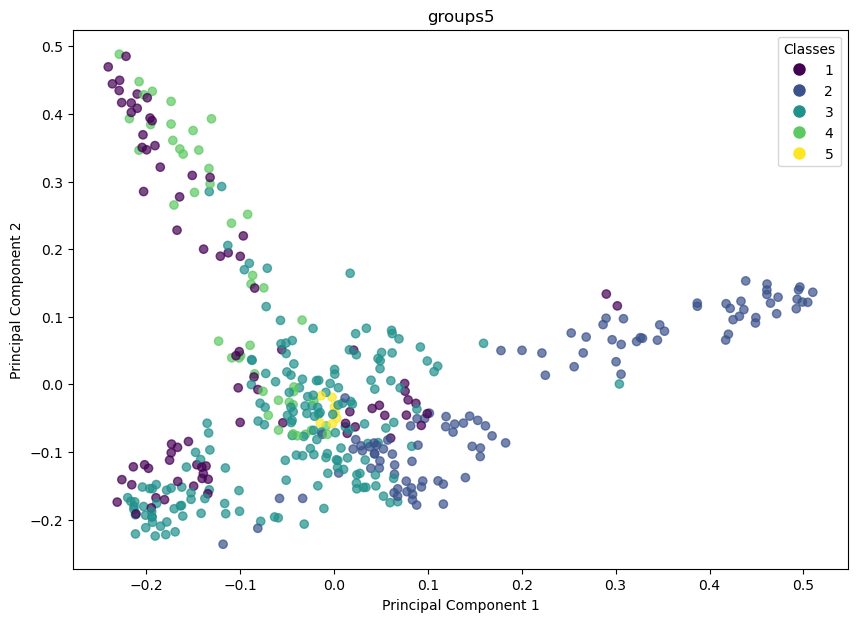

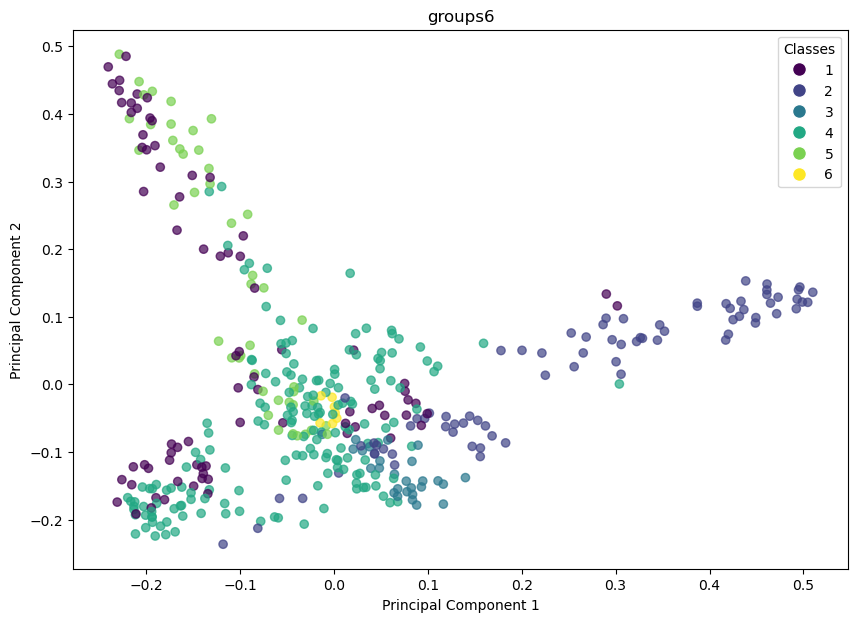

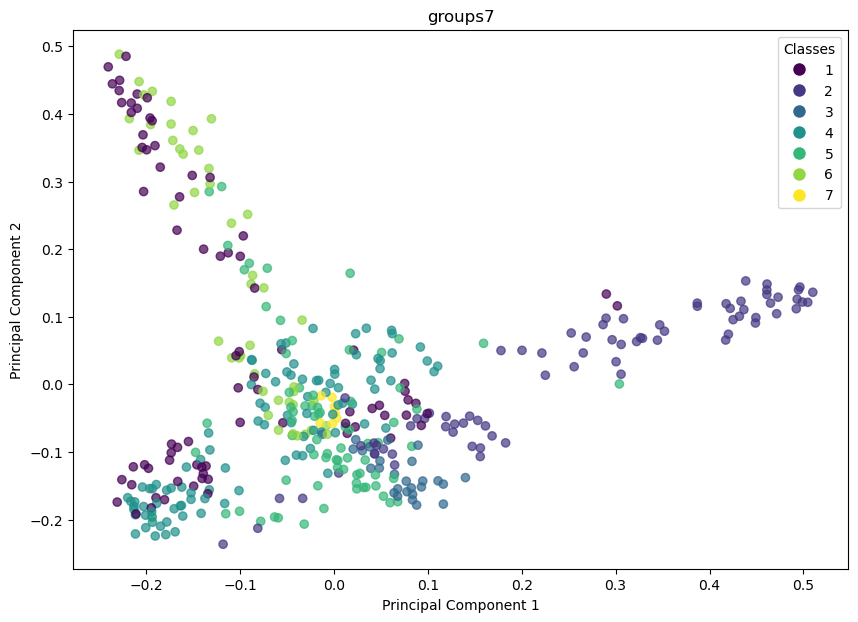

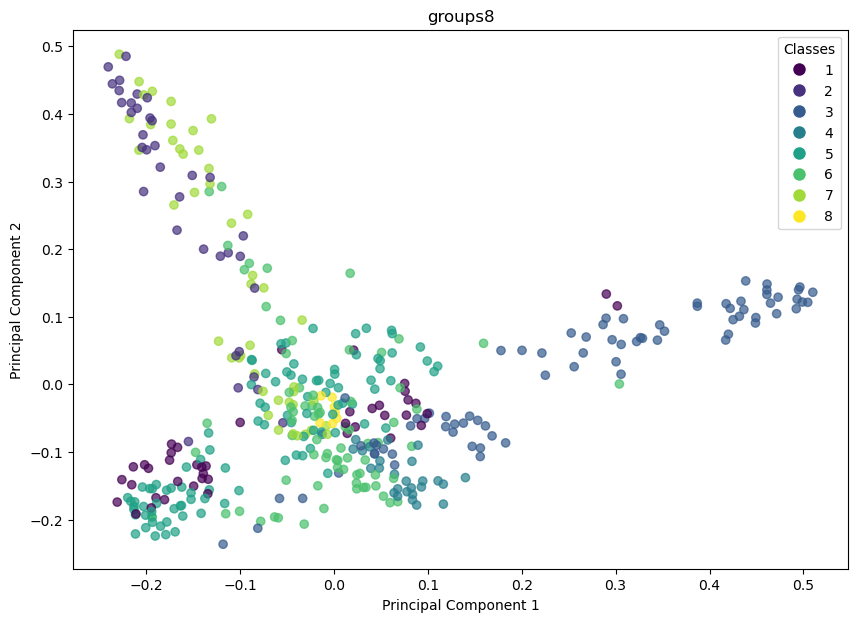

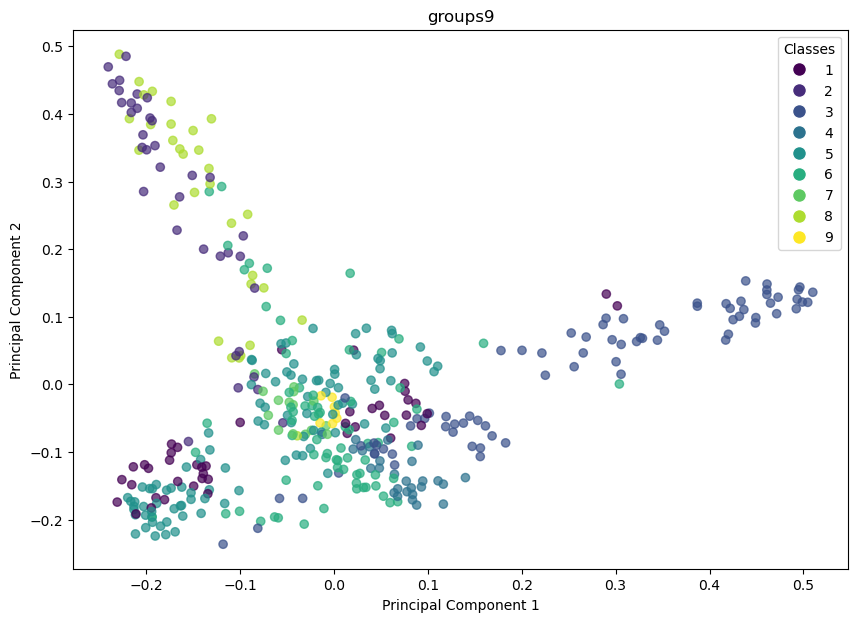

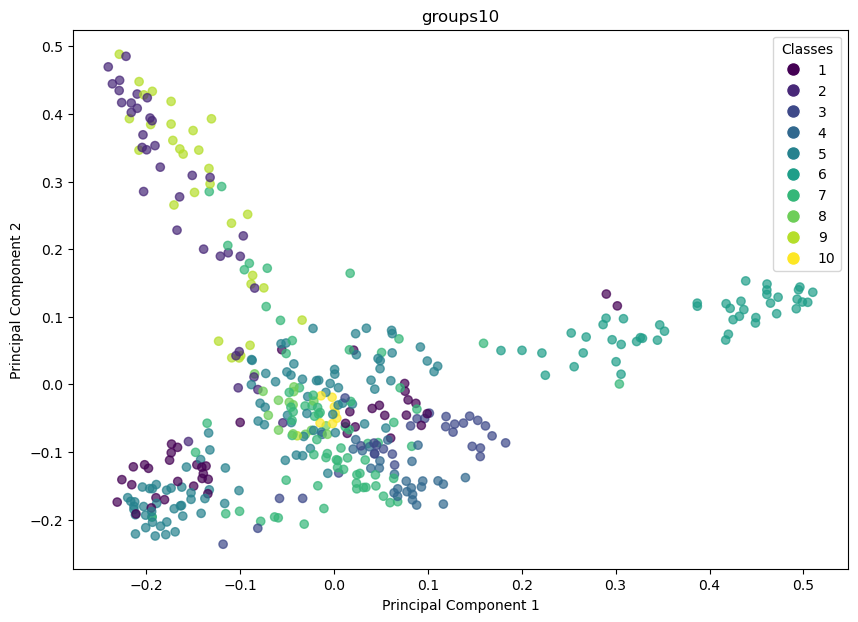

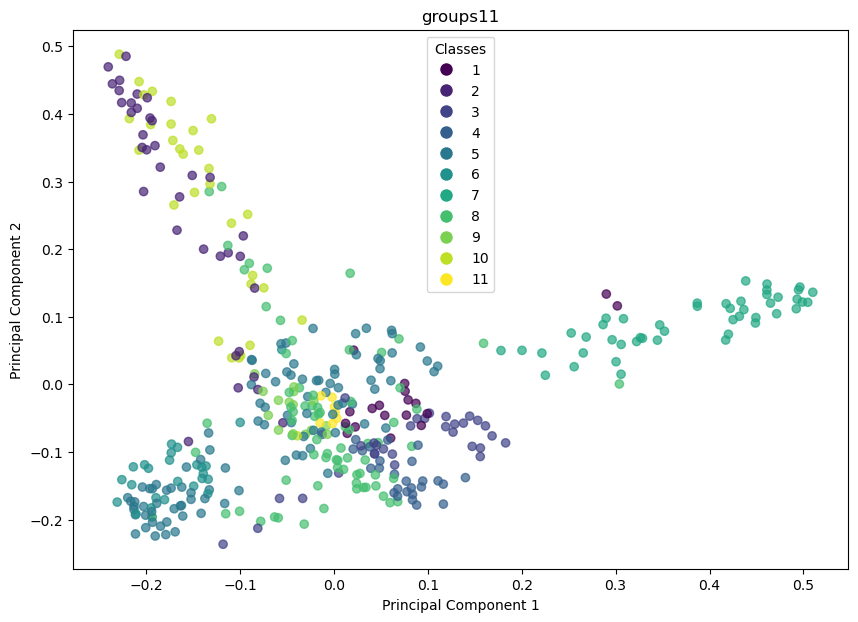

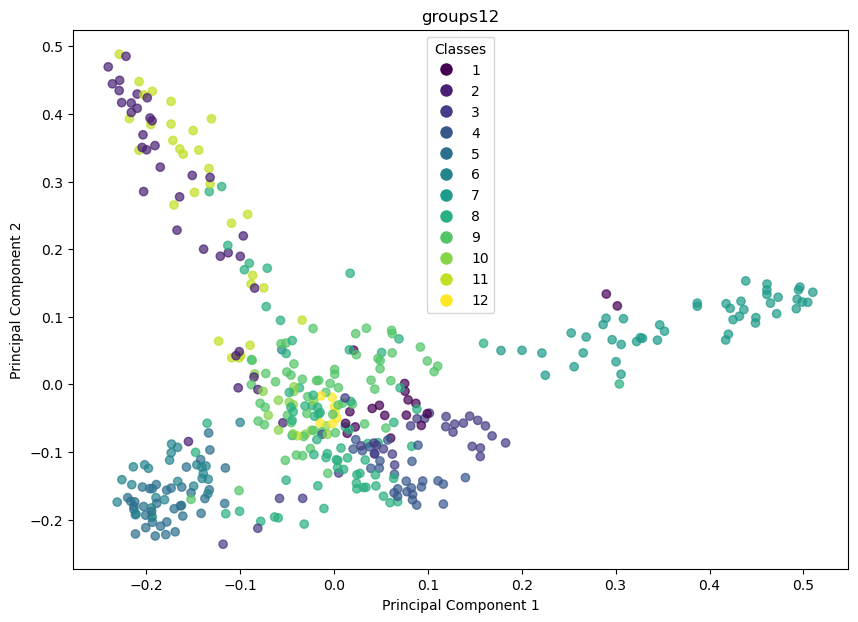

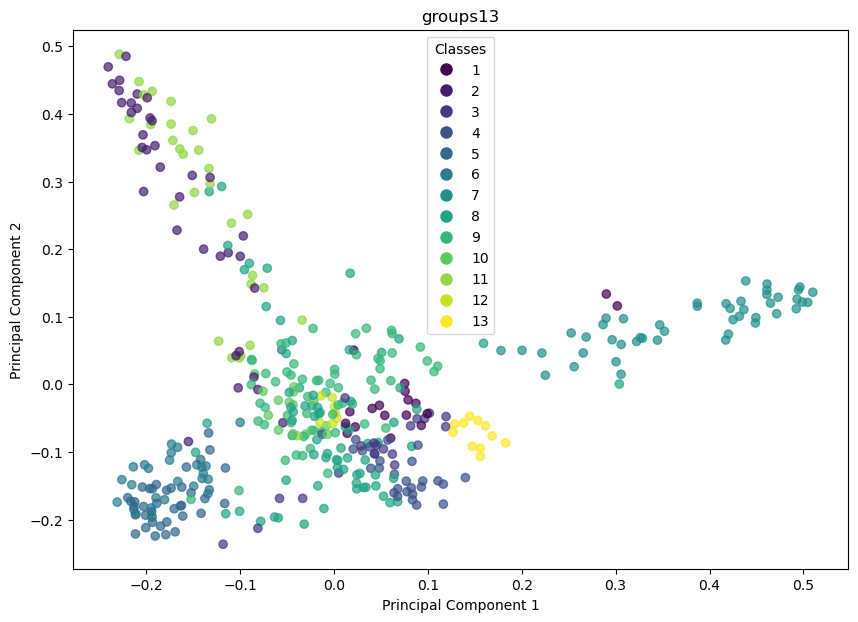

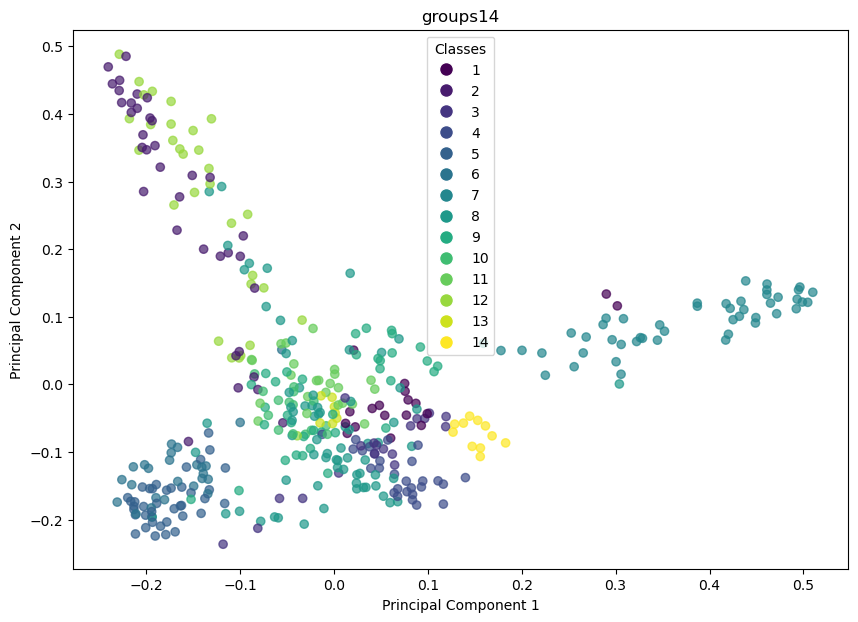

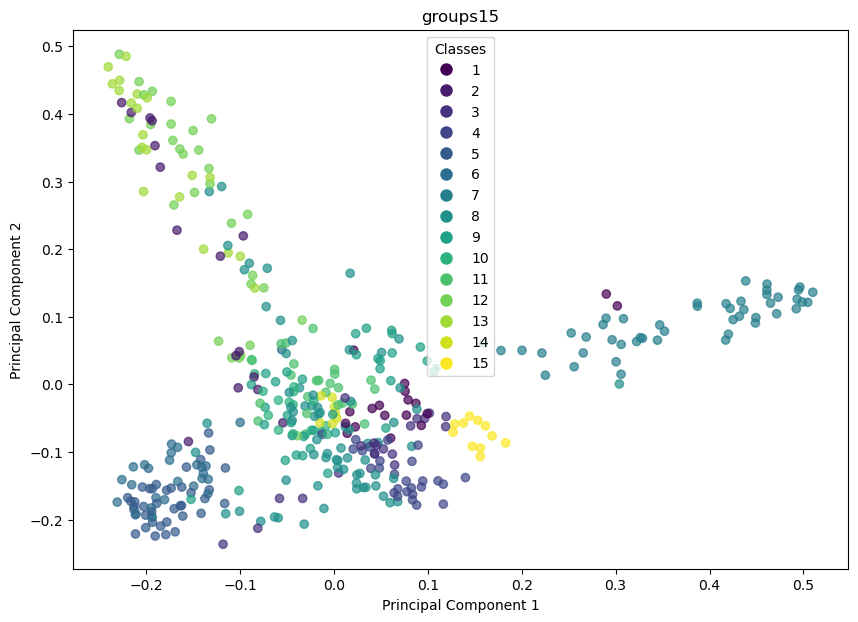

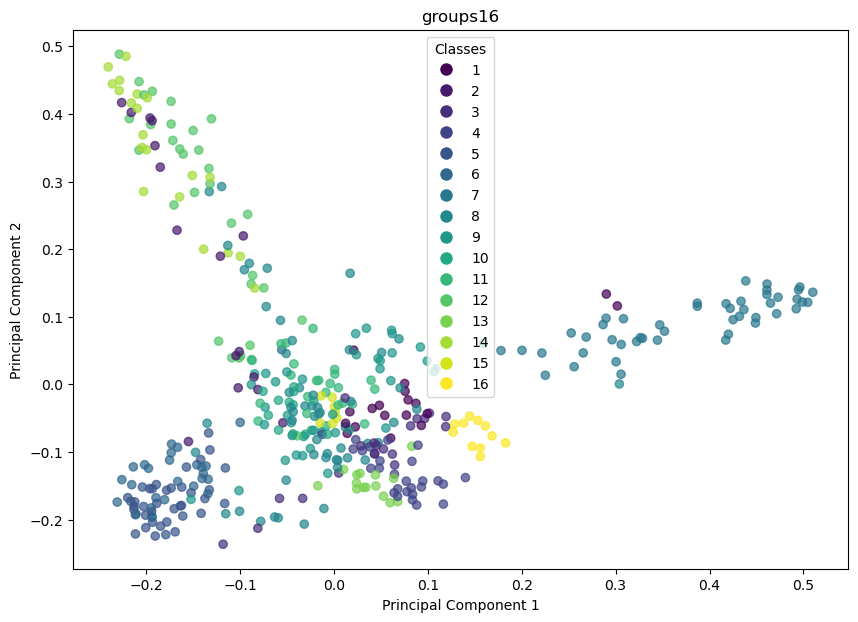

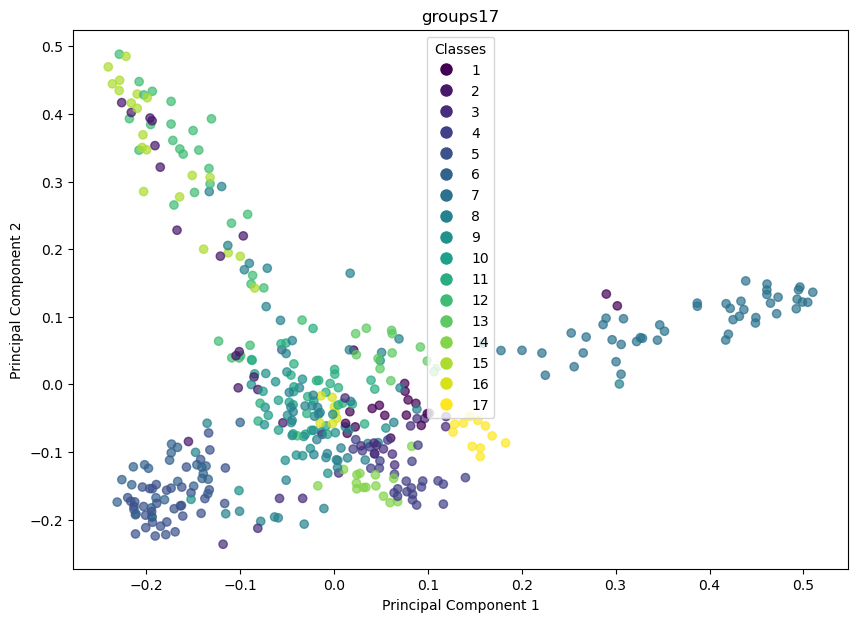

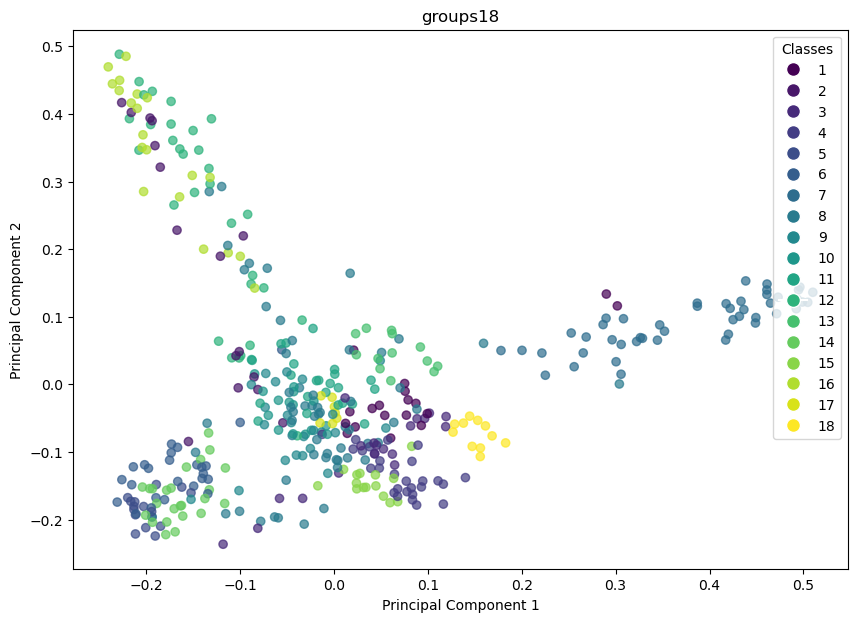

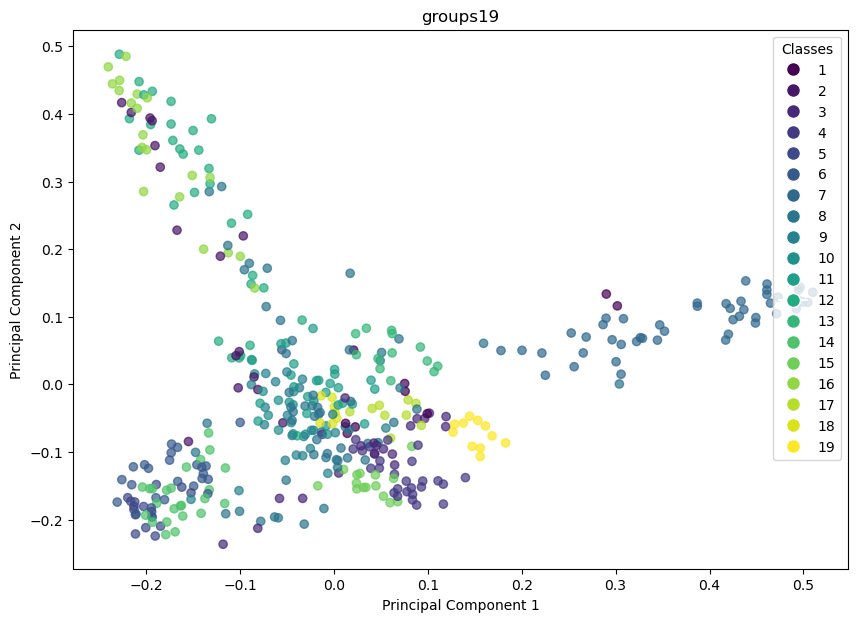

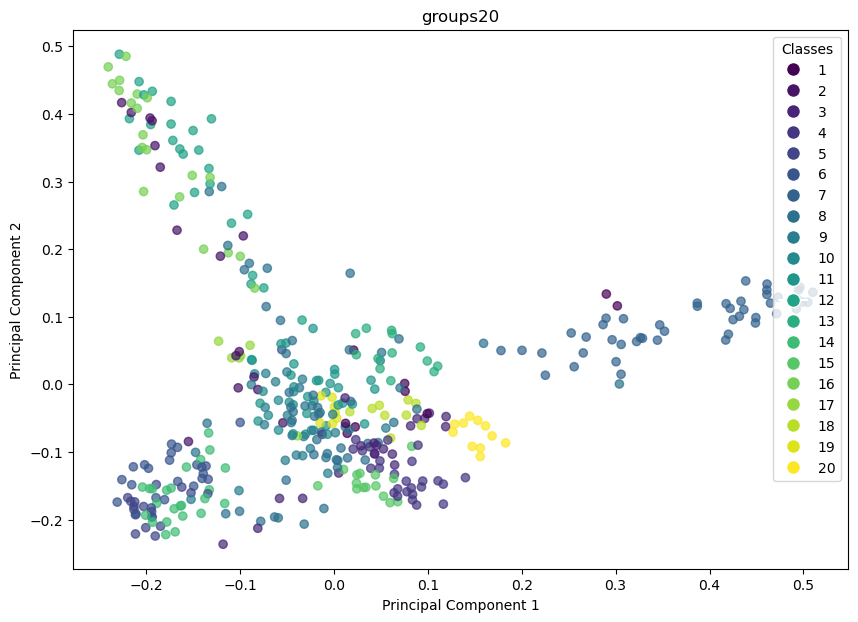

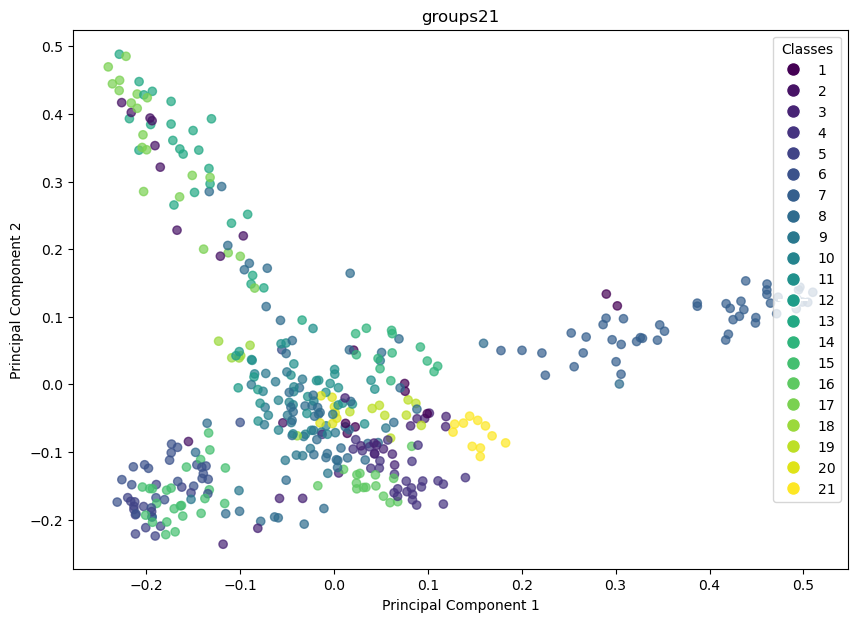

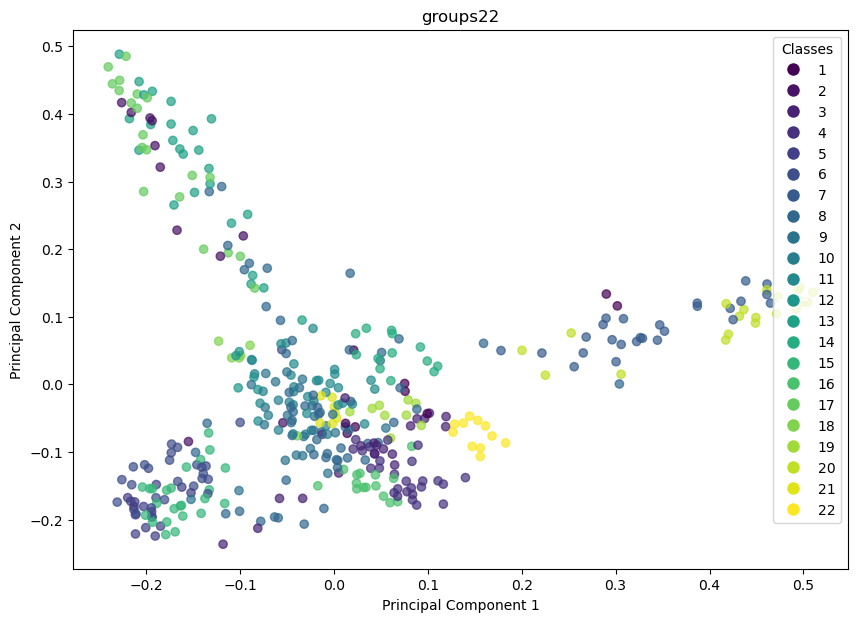

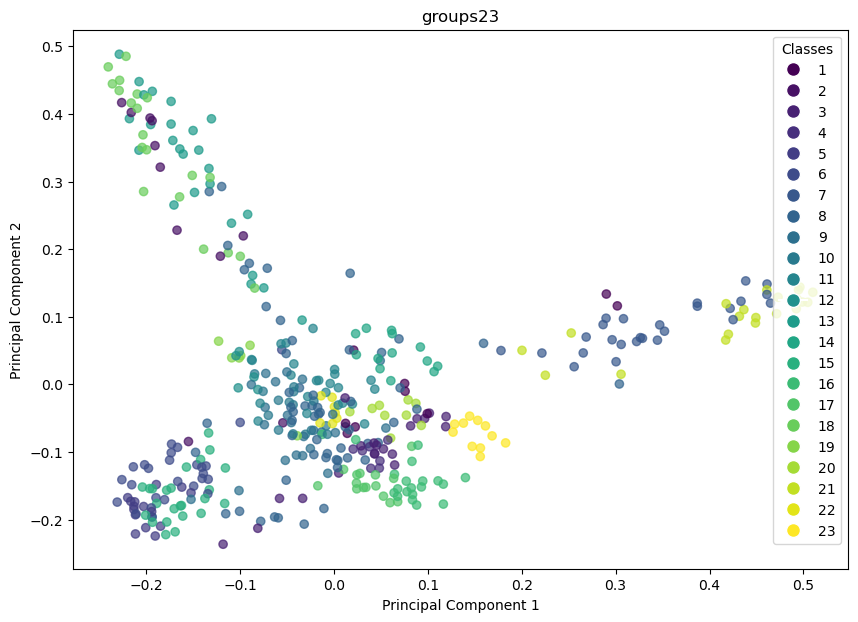

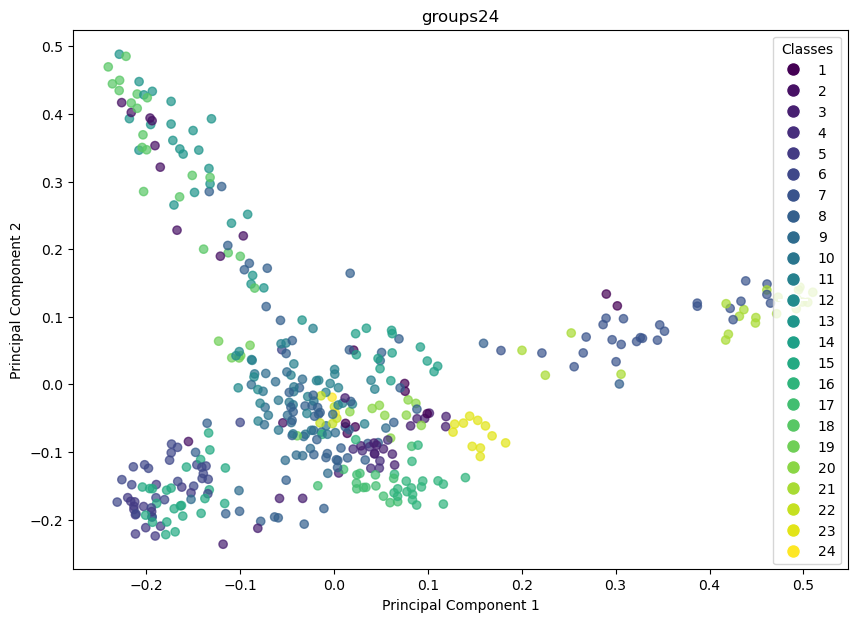

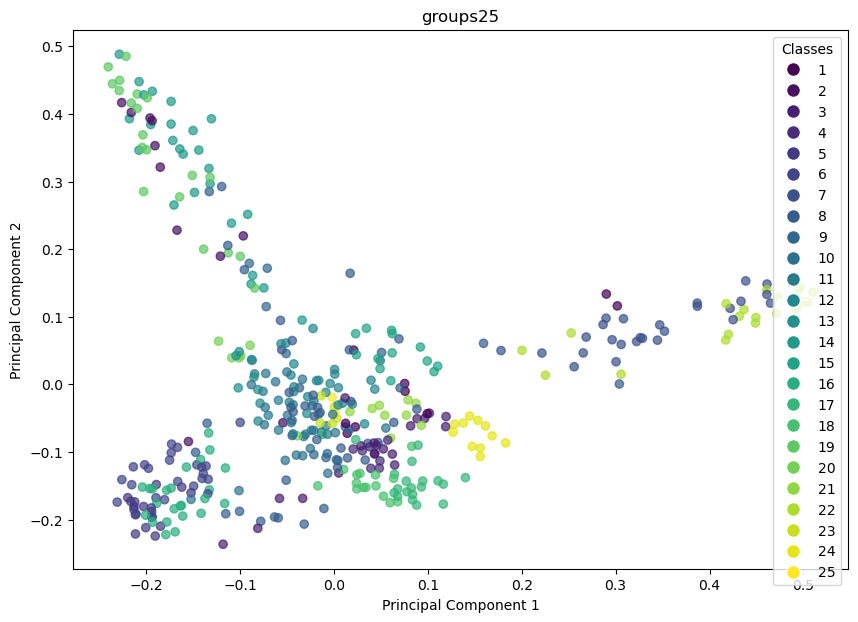

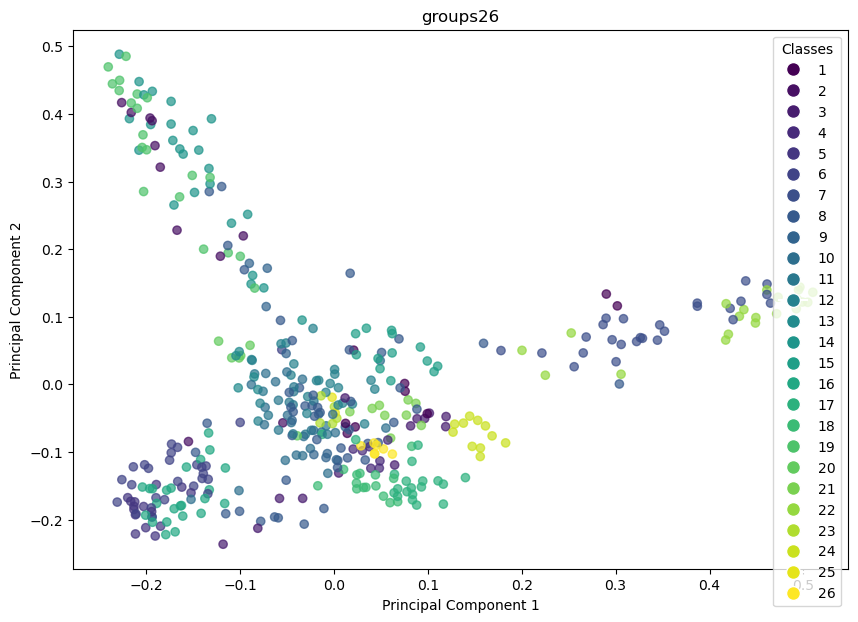

In [340]:
for g in groups.columns[1:]:
    fig = ploty_pca(ddd, groups.loc[:,g], g)
    fig.savefig(f'{g}_pca.png', bbox_inches='tight')